In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as  plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import OneClassSVM
from itertools import product
from sklearn.model_selection import train_test_split
from sklearn.metrics import fbeta_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


In [2]:
trainDf=pd.read_csv('iec104_custom_script_train_final.csv')
testDf=pd.read_csv('iec104_custom_script_test_final.csv')
df_80,df_20=train_test_split(
    trainDf,
    test_size=0.20,
    stratify=trainDf['Label'],
    random_state=63
)

print(df_20['Label'].value_counts())
print(df_80['Label'].value_counts())

fit_normals=df_80[df_80['Label']=='NORMAL']
dev_set=pd.concat([df_20,df_80[df_80['Label']!='NORMAL']])


#drop the Labels from X_train/dev/test and just keep the label on y_train/test
X_train=fit_normals.drop('Label',axis=1)
X_dev=dev_set.drop('Label',axis=1)
y_dev_real=dev_set['Label'].apply(lambda label:1 if label=='NORMAL' else -1)
X_test=testDf.drop('Label',axis=1)
y_test=testDf['Label'].apply(lambda label:1 if label=='NORMAL' else -1)
y_dev_bin=(y_dev_real==-1)
y_test_bin=(y_test==-1)

Label
c_sc_na_1_DoS    80
c_rd_na_1_DoS    80
c_rp_na_1        80
c_ci_na_1        80
m_sp_na_1_DoS    80
c_rp_na_1_DoS    80
c_rd_na_1        80
c_ci_na_1_DoS    80
c_se_na_1        80
c_sc_na_1        80
NORMAL           80
c_se_na_1_DoS    80
Name: count, dtype: int64
Label
c_sc_na_1_DoS    320
c_rp_na_1        320
c_rp_na_1_DoS    320
m_sp_na_1_DoS    320
c_ci_na_1_DoS    320
NORMAL           320
c_rd_na_1        320
c_se_na_1_DoS    320
c_rd_na_1_DoS    320
c_sc_na_1        320
c_ci_na_1        320
c_se_na_1        320
Name: count, dtype: int64


 Accuracy Score: 1.0
 100 | 0.01   | fbeta=1.0000


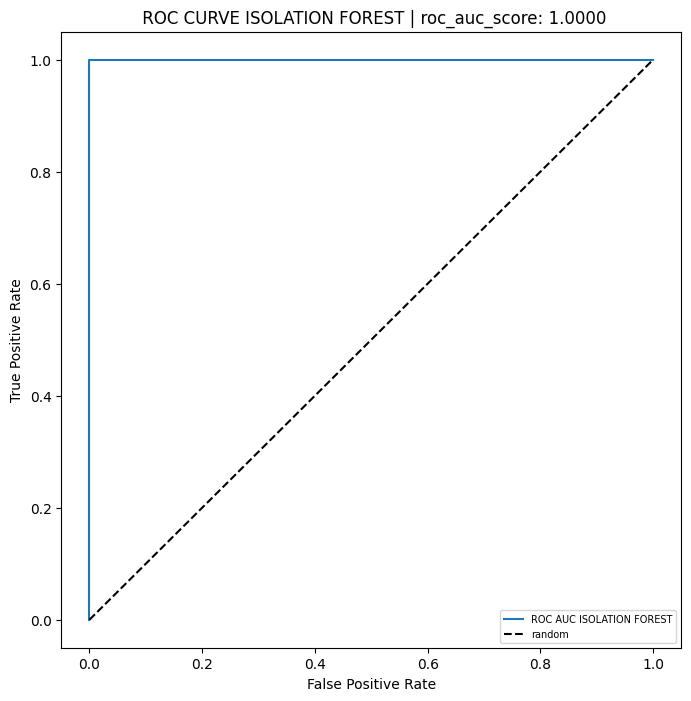

 Accuracy Score: 1.0
 100 | 0.02   | fbeta=1.0000
 Accuracy Score: 1.0
 100 | 0.033  | fbeta=1.0000
 Accuracy Score: 0.9997767857142857
 100 | 0.05   | fbeta=1.0000
 Accuracy Score: 0.9984375
 100 | 0.1    | fbeta=0.9997
 Accuracy Score: 0.9973214285714286
 100 | 0.2    | fbeta=0.9995
 Accuracy Score: 1.0
 200 | 0.01   | fbeta=1.0000


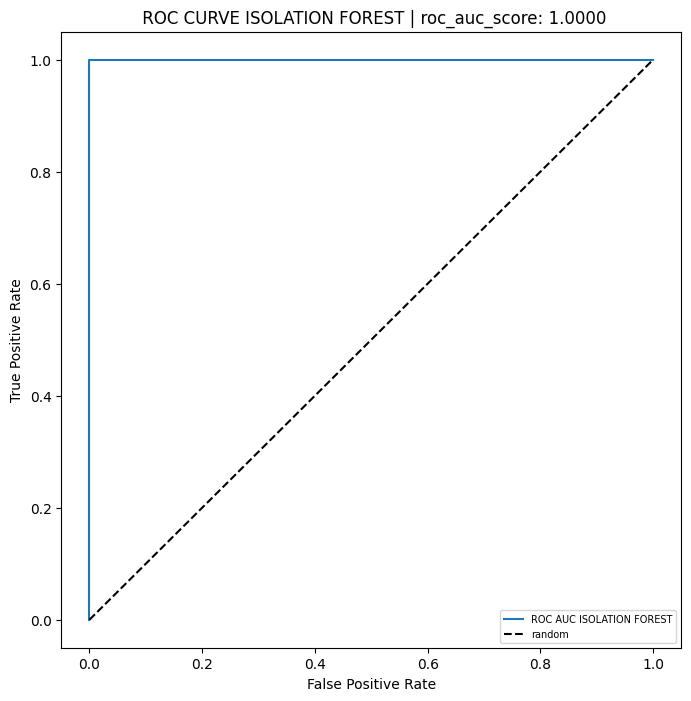

 Accuracy Score: 1.0
 200 | 0.02   | fbeta=1.0000
 Accuracy Score: 0.9997767857142857
 200 | 0.033  | fbeta=1.0000
 Accuracy Score: 0.9995535714285714
 200 | 0.05   | fbeta=0.9999
 Accuracy Score: 0.9979910714285715
 200 | 0.1    | fbeta=0.9996
 Accuracy Score: 0.9973214285714286
 200 | 0.2    | fbeta=0.9995
 Accuracy Score: 1.0
 300 | 0.01   | fbeta=1.0000


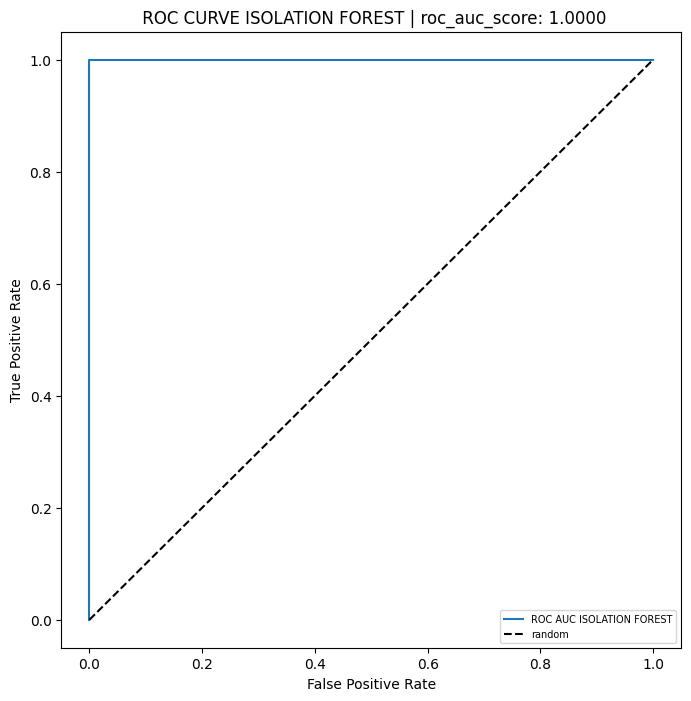

 Accuracy Score: 1.0
 300 | 0.02   | fbeta=1.0000
 Accuracy Score: 0.9997767857142857
 300 | 0.033  | fbeta=1.0000
 Accuracy Score: 0.9995535714285714
 300 | 0.05   | fbeta=0.9999
 Accuracy Score: 0.9979910714285715
 300 | 0.1    | fbeta=0.9996
 Accuracy Score: 0.9973214285714286
 300 | 0.2    | fbeta=0.9995
1.0
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      4400
      Normal       1.00      1.00      1.00        80

    accuracy                           1.00      4480
   macro avg       1.00      1.00      1.00      4480
weighted avg       1.00      1.00      1.00      4480

(0.01, 100)


In [3]:

best=0
n_estimators_unseen=1
for n_estimators,contamination in product([100,200,300],[0.01,0.02,0.033,0.05,0.1,0.2]):
    ilf=IsolationForest(
        n_estimators = n_estimators,
        contamination=contamination,
        random_state=63
    )
    if n_estimators_unseen!=n_estimators:
        unseen=True
        n_estimators_unseen=n_estimators
    ilf.fit(X_train)
    pred=ilf.predict(X_dev)
    
    print(f' Accuracy Score: {accuracy_score(y_dev_real,pred)}')
    fbeta=fbeta_score(y_dev_real,pred,beta=2,pos_label=-1)
    if fbeta>best:
        best=fbeta
        best_con_est=contamination,n_estimators
        best_classification_report=classification_report(y_dev_real, pred, target_names=['Attack', 'Normal'])    
    print(f'{n_estimators:>4} | {contamination:<6} | fbeta={fbeta:.4f}')
    if unseen:
            ilf_score=ilf.score_samples(X_dev)
            fpr,tpr,_=roc_curve(y_dev_bin,-ilf_score)
            ilf_auc=roc_auc_score(y_dev_bin,-ilf_score)
            plt.figure(figsize=(8,8))
            plt.plot(fpr,tpr,label='ROC AUC ISOLATION FOREST')
            plt.plot([0,1],[0,1],'k--',label='random')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.legend(loc='lower right',fontsize=7)
            plt.title(f' ROC CURVE ISOLATION FOREST | roc_auc_score: {ilf_auc:.4f}')
            plt.show()
    unseen=False
print(best)
print(best_classification_report)
print(best_con_est)



              precision    recall  f1-score   support

          -1       1.00      1.00      1.00      1859
           1       1.00      0.98      0.99       169

    accuracy                           1.00      2028
   macro avg       1.00      0.99      1.00      2028
weighted avg       1.00      1.00      1.00      2028



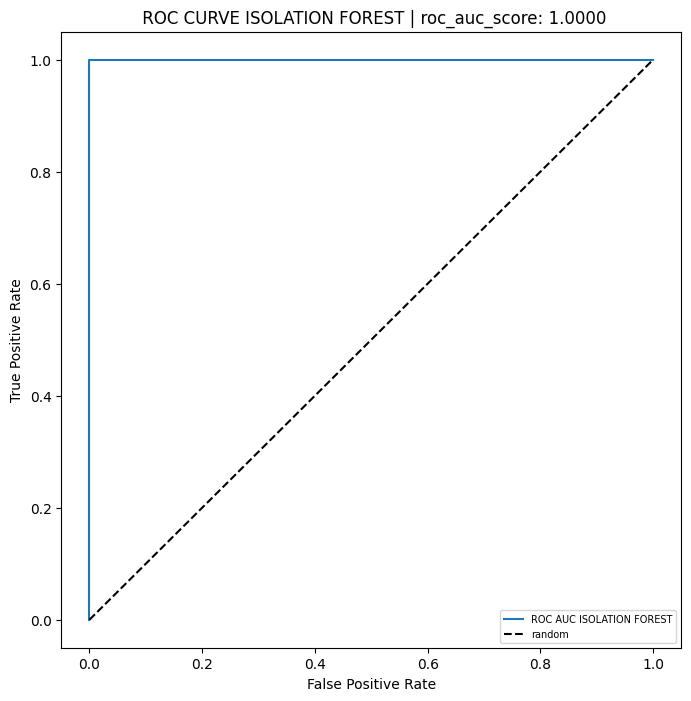

In [4]:
final_ilf = IsolationForest(contamination=0.033, n_estimators=100, random_state=63)
final_ilf.fit(X_train)
final_ilf_pred=final_ilf.predict(X_test)
print(classification_report(y_test,final_ilf_pred))

ilf_score=final_ilf.score_samples(X_test)
fpr,tpr,_=roc_curve(y_test_bin,-ilf_score)
ilf_auc=roc_auc_score(y_test,ilf_score)
plt.figure(figsize=(8,8))
plt.plot(fpr,tpr,label='ROC AUC ISOLATION FOREST')
plt.plot([0,1],[0,1],'k--',label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right',fontsize=7)
plt.title(f' ROC CURVE ISOLATION FOREST | roc_auc_score: {ilf_auc:.4f}')
plt.show()

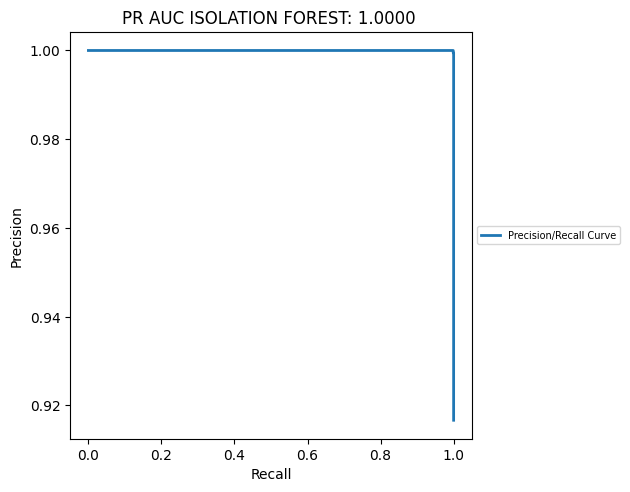

In [5]:
from sklearn.metrics import precision_recall_curve,average_precision_score
ilf_score=final_ilf.score_samples(X_test)

precisions,recalls,threshold = precision_recall_curve(y_test_bin,-ilf_score)
plt.plot(recalls,precisions,linewidth=2,label='Precision/Recall Curve')   
plt.xlabel('Recall')
macro_ap = average_precision_score(y_test_bin, -ilf_score, average='macro')

plt.ylabel('Precision')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=7)
plt.tight_layout()
plt.title(f'PR AUC ISOLATION FOREST: {macro_ap:.4f} ')
plt.show()

nu: 0.0100 | gamma : 0.0010 fbeta= 0.9999 AUC= 0.9894


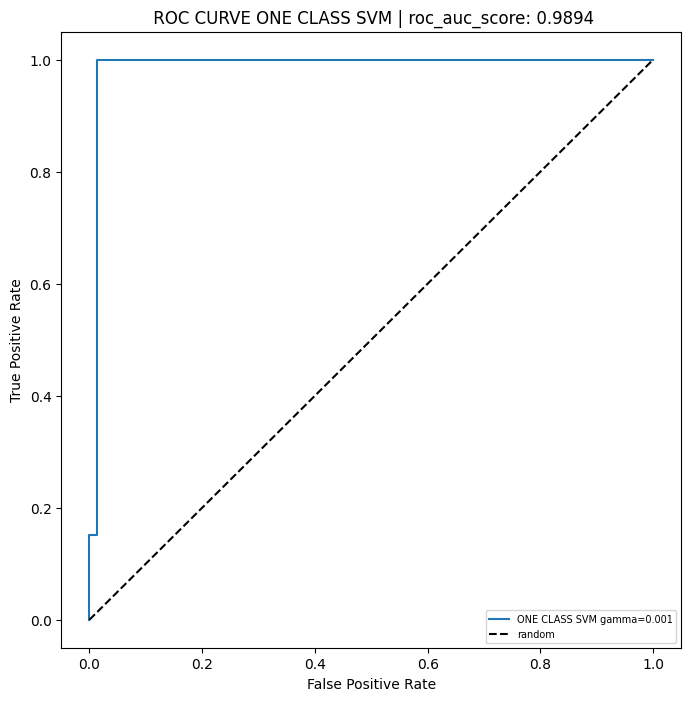

nu: 0.0100 | gamma : 0.0100 fbeta= 0.9996 AUC= 0.9894


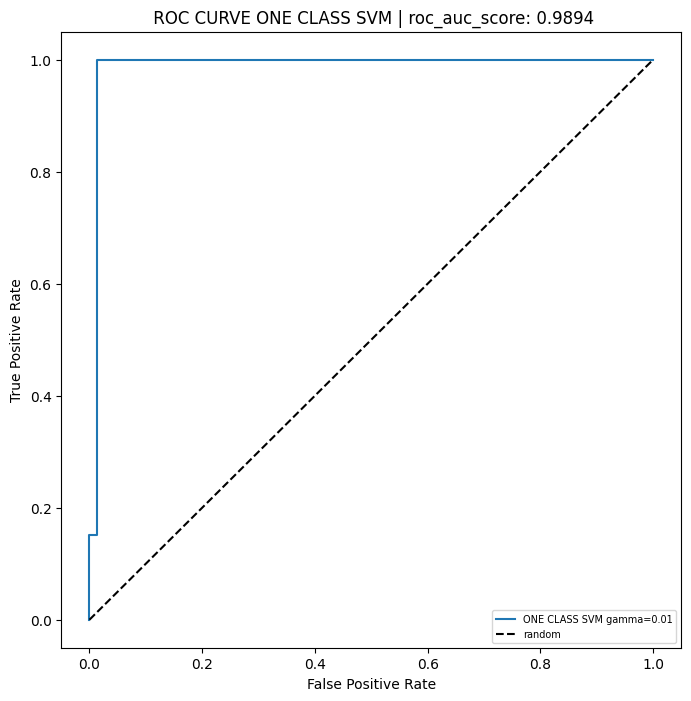

nu: 0.0100 | gamma : 0.1000 fbeta= 0.9974 AUC= 0.9937


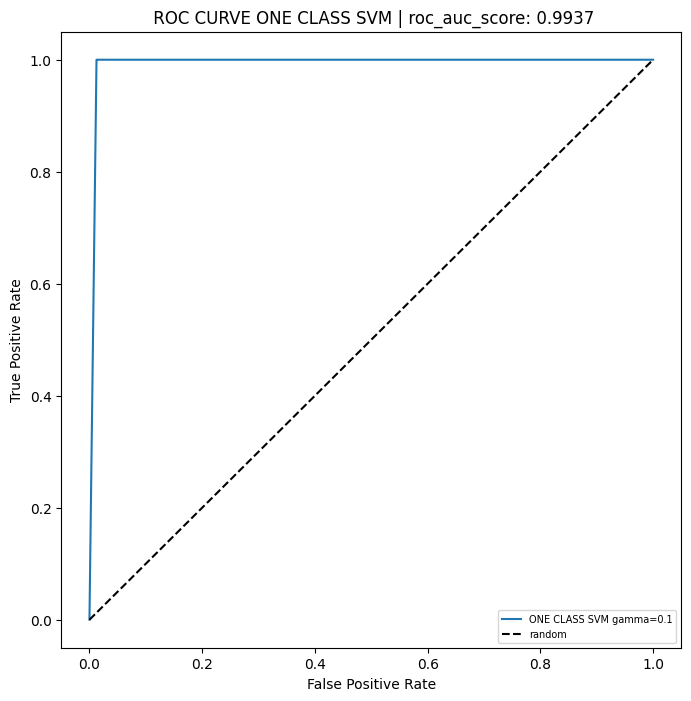

nu: 0.0300 | gamma : 0.0010 fbeta= 1.0000 AUC= 0.9894
nu: 0.0300 | gamma : 0.0100 fbeta= 0.9996 AUC= 0.9894
nu: 0.0300 | gamma : 0.1000 fbeta= 0.9974 AUC= 0.9937
nu: 0.0500 | gamma : 0.0010 fbeta= 0.9999 AUC= 0.9895
nu: 0.0500 | gamma : 0.0100 fbeta= 0.9996 AUC= 0.9894
nu: 0.0500 | gamma : 0.1000 fbeta= 0.9974 AUC= 0.9937
nu: 0.1000 | gamma : 0.0010 fbeta= 0.9997 AUC= 0.9896
nu: 0.1000 | gamma : 0.0100 fbeta= 0.9996 AUC= 0.9894
nu: 0.1000 | gamma : 0.1000 fbeta= 0.9974 AUC= 0.9937
(0.03, 0.001)
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      4400
      Normal       1.00      0.99      0.99        80

    accuracy                           1.00      4480
   macro avg       1.00      0.99      1.00      4480
weighted avg       1.00      1.00      1.00      4480

0.9999545475205672


In [6]:
best=-1
unseen_gamma=set()
scale=StandardScaler()
X_train_normal_scaled=scale.fit_transform(X_train)
X_dev_scaled=scale.transform(X_dev)
X_test_scaled=scale.transform(X_test)
for nu,gamma in product([0.01,0.03,0.05,0.1],[0.001,0.01,0.1]):
    svm=OneClassSVM(
        nu=nu,
        gamma=gamma,
        )
    svm.fit(X_train_normal_scaled)
    pred_svm=svm.predict(X_dev_scaled)
    fbeta=fbeta_score(y_dev_real,pred_svm,pos_label=-1,beta=2)
    svm_score=svm.score_samples(X_dev_scaled)
    svm_auc = roc_auc_score(y_dev_bin, -svm_score)
    if fbeta>best:
        best=fbeta
        best_nu_gamma=nu,gamma
        best_classification_report=classification_report(y_dev_real,pred_svm,labels=[-1,1],target_names=['Attack','Normal'])
    print(f'nu: {nu:.4f} | gamma : {gamma:.4f} fbeta= {fbeta:.4f} AUC= {svm_auc:.4f}')
    if gamma not in unseen_gamma:
        unseen = True
        unseen_gamma.add(gamma)
    if unseen:
        fpr,tpr,_=roc_curve(y_dev_bin,-svm_score)
        plt.figure(figsize=(8,8))
        plt.plot(fpr,tpr,label=f'ONE CLASS SVM gamma={gamma}')
        plt.plot([0,1],[0,1],'k--',label='random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right',fontsize=7)
        plt.title(f' ROC CURVE ONE CLASS SVM | roc_auc_score: {svm_auc:.4f}')
        plt.show()
    unseen = False
        
print(best_nu_gamma)
print(best_classification_report)
print(best)

              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      1859
      Normal       1.00      0.97      0.98       169

    accuracy                           1.00      2028
   macro avg       1.00      0.99      0.99      2028
weighted avg       1.00      1.00      1.00      2028



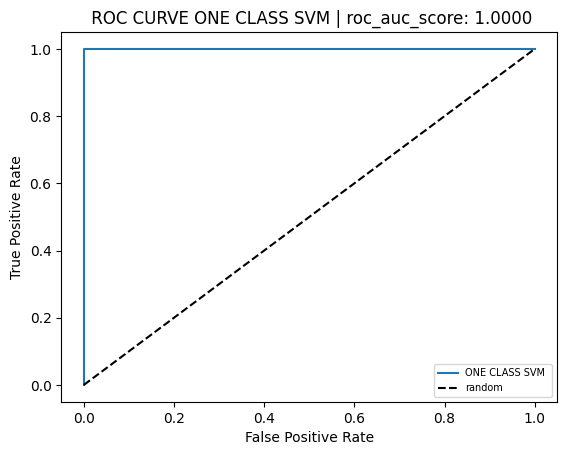

In [7]:
final_svm=OneClassSVM(nu=0.01,gamma=0.001)
final_svm.fit(X_train_normal_scaled)
final_svm_pred=final_svm.predict(X_test_scaled)
print(classification_report(y_test,final_svm_pred,labels=[-1,1],target_names=['Attack','Normal']))
svm_score=final_svm.score_samples(X_test_scaled)
fpr,tpr,_=roc_curve(y_test_bin,-svm_score)
svm_auc=roc_auc_score(y_test,svm_score)
plt.plot(fpr,tpr,label='ONE CLASS SVM ')
plt.plot([0,1],[0,1],'k--',label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right',fontsize=7)
plt.title(f' ROC CURVE ONE CLASS SVM | roc_auc_score: {svm_auc:.4f}')
plt.show()

In [8]:
import torch 
import torch.nn as nn
torch.manual_seed(63)
n_features = X_train.shape[1]
loss_history = []
encoder = nn.Sequential(
    nn.Linear(n_features,n_features//2),
    nn.Sigmoid(),
    nn.Linear(n_features//2,n_features//4),
    nn.Sigmoid()
)
decoder =nn.Sequential(
    nn.Linear(n_features//4,n_features//2),
    nn.Sigmoid(),
    nn.Linear(n_features//2,n_features)
)
X_train_normal_tensor=torch.FloatTensor(X_train_normal_scaled)

autoencoder=nn.Sequential(encoder,decoder)
loss_function=nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
epochs=1000

for epoch in range(epochs):
    outputs=(autoencoder(X_train_normal_tensor))
    losses=(loss_function(outputs,X_train_normal_tensor))
    optimizer.zero_grad()
    losses.backward()
    optimizer.step()
    loss_history.append(losses.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {losses.item():.4f}")              


Epoch 0, Loss: 0.8207
Epoch 10, Loss: 0.7417
Epoch 20, Loss: 0.7304
Epoch 30, Loss: 0.7272
Epoch 40, Loss: 0.7226
Epoch 50, Loss: 0.7143
Epoch 60, Loss: 0.6986
Epoch 70, Loss: 0.6706
Epoch 80, Loss: 0.6275
Epoch 90, Loss: 0.5742
Epoch 100, Loss: 0.5210
Epoch 110, Loss: 0.4734
Epoch 120, Loss: 0.4318
Epoch 130, Loss: 0.3994
Epoch 140, Loss: 0.3768
Epoch 150, Loss: 0.3613
Epoch 160, Loss: 0.3507
Epoch 170, Loss: 0.3434
Epoch 180, Loss: 0.3383
Epoch 190, Loss: 0.3347
Epoch 200, Loss: 0.3319
Epoch 210, Loss: 0.3298
Epoch 220, Loss: 0.3280
Epoch 230, Loss: 0.3266
Epoch 240, Loss: 0.3253
Epoch 250, Loss: 0.3242
Epoch 260, Loss: 0.3231
Epoch 270, Loss: 0.3222
Epoch 280, Loss: 0.3212
Epoch 290, Loss: 0.3203
Epoch 300, Loss: 0.3193
Epoch 310, Loss: 0.3182
Epoch 320, Loss: 0.3170
Epoch 330, Loss: 0.3154
Epoch 340, Loss: 0.3134
Epoch 350, Loss: 0.3107
Epoch 360, Loss: 0.3069
Epoch 370, Loss: 0.3018
Epoch 380, Loss: 0.2956
Epoch 390, Loss: 0.2890
Epoch 400, Loss: 0.2830
Epoch 410, Loss: 0.2780
Epo

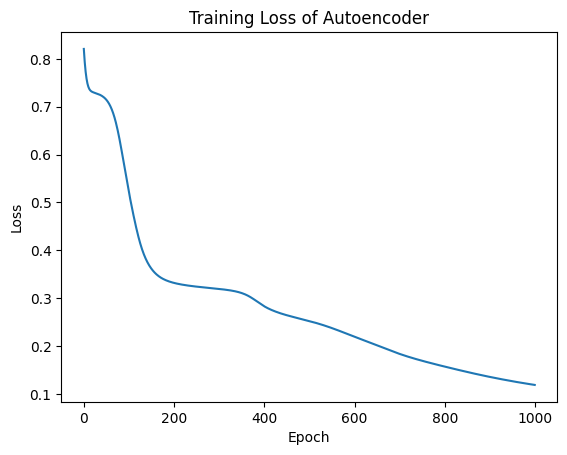

In [9]:
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss of Autoencoder')
plt.show()

As the number of epochs progresses the reconstruction loss of the normal samples reduces 

              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      4400
      Normal       1.00      0.97      0.99        80

    accuracy                           1.00      4480
   macro avg       1.00      0.99      0.99      4480
weighted avg       1.00      1.00      1.00      4480

0.9995535714285714


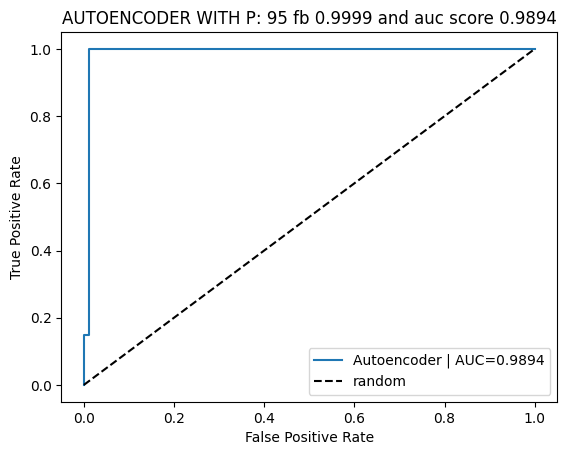

              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      4400
      Normal       1.00      0.97      0.99        80

    accuracy                           1.00      4480
   macro avg       1.00      0.99      0.99      4480
weighted avg       1.00      1.00      1.00      4480

0.9995535714285714


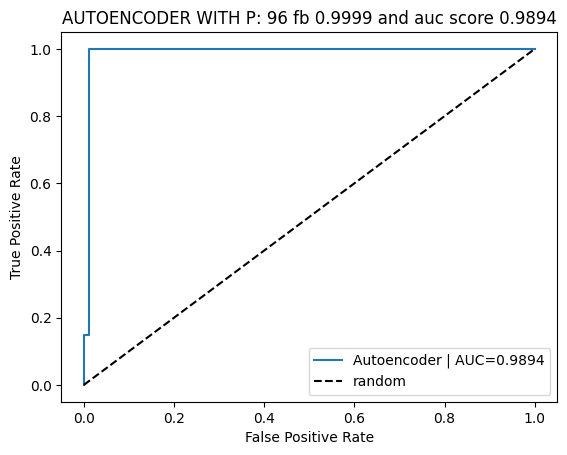

              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      4400
      Normal       1.00      0.97      0.99        80

    accuracy                           1.00      4480
   macro avg       1.00      0.99      0.99      4480
weighted avg       1.00      1.00      1.00      4480

0.9995535714285714


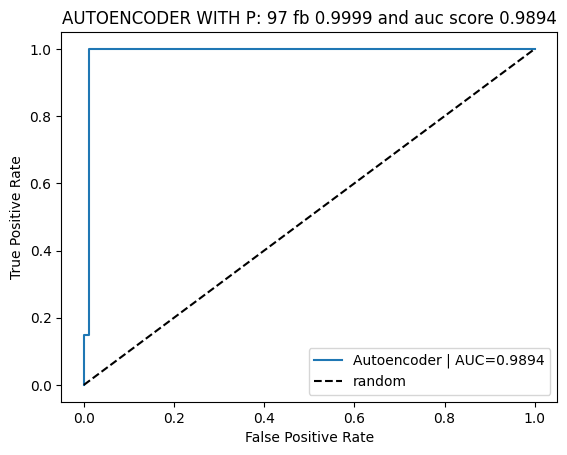

              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      4400
      Normal       1.00      0.97      0.99        80

    accuracy                           1.00      4480
   macro avg       1.00      0.99      0.99      4480
weighted avg       1.00      1.00      1.00      4480

0.9995535714285714


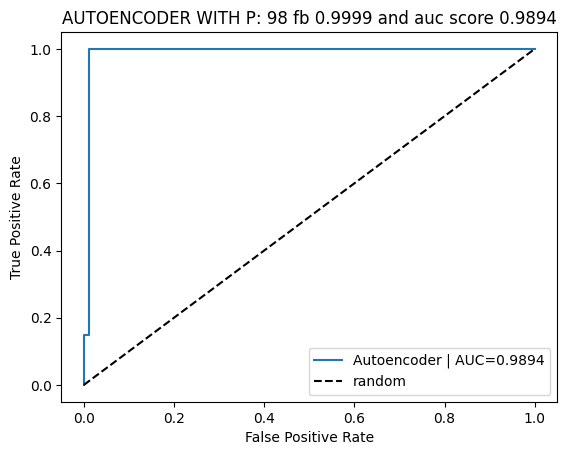

              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00      4400
      Normal       1.00      0.97      0.99        80

    accuracy                           1.00      4480
   macro avg       1.00      0.99      0.99      4480
weighted avg       1.00      1.00      1.00      4480

0.9995535714285714


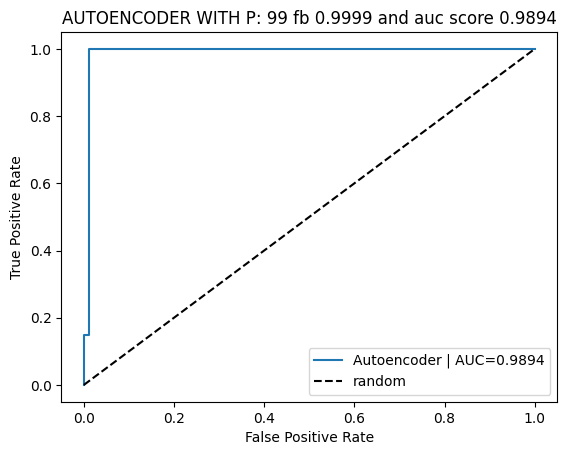

0.9999090991728025 95


In [10]:
X_dev_tensor=torch.FloatTensor(X_dev_scaled)
X_test_tensor=torch.FloatTensor(X_test_scaled)
with torch.no_grad():
    train_errors = torch.mean((X_train_normal_tensor - autoencoder(X_train_normal_tensor))**2, dim=1).numpy()
    dev_errors = torch.mean((X_dev_tensor- autoencoder(X_dev_tensor))**2, dim=1).numpy()
best=-1
for p in [95,96,97,98,99]:
    threshold = np.percentile(train_errors, p)     
    pred_ae = np.where(dev_errors > threshold, -1, 1)
    print(classification_report(y_dev_real, pred_ae,labels=[-1,1] ,target_names=['Attack','Normal']))
    print(accuracy_score(y_dev_real,pred_ae))
    y_dev_bin=(y_dev_real==-1)
    ae_auc_score=roc_auc_score(y_dev_bin,dev_errors)
    fpr,tpr,_=roc_curve(y_dev_bin,dev_errors)
    fb=fbeta_score(y_dev_real,pred_ae,pos_label=-1,beta=2)
    if fb>best:
        best,best_p=fb,p
    plt.plot(fpr, tpr, label=f'Autoencoder | AUC={ae_auc_score:.4f}')
    plt.plot([0,1], [0,1], 'k--', label='random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.title(f'AUTOENCODER WITH P: {p} fb {fb:.4f} and auc score {ae_auc_score:.4f}')
    plt.show()
print(best,best_p)




              precision    recall  f1-score   support

      Attack       0.99      1.00      1.00      1859
      Normal       1.00      0.92      0.96       169

    accuracy                           0.99      2028
   macro avg       1.00      0.96      0.98      2028
weighted avg       0.99      0.99      0.99      2028



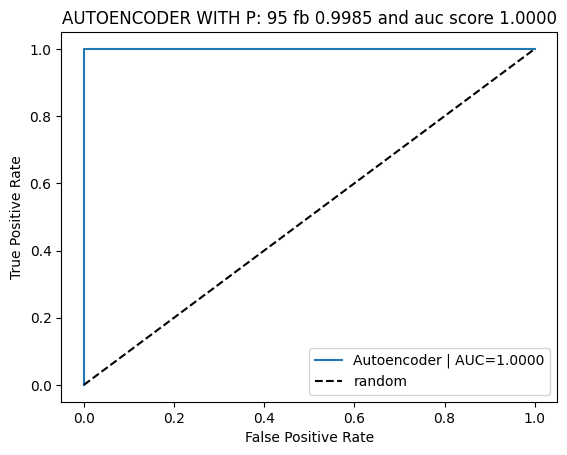

In [11]:
with torch.no_grad():
    test_errors = torch.mean((X_test_tensor - autoencoder(X_test_tensor))**2, dim=1).numpy()

thr = np.percentile(train_errors, best_p)
pred_ae = np.where(test_errors > thr, -1, 1)
print(classification_report(y_test, pred_ae, labels=[-1,1], target_names=['Attack','Normal']))
y_test_bin=(y_test==-1)
ae_auc_score=roc_auc_score(y_test_bin,test_errors)
fpr,tpr,_=roc_curve(y_test_bin,test_errors)
fb=fbeta_score(y_test,pred_ae,pos_label=-1,beta=2)
plt.plot(fpr, tpr, label=f'Autoencoder | AUC={ae_auc_score:.4f}')
plt.plot([0,1], [0,1], 'k--', label='random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.title(f'AUTOENCODER WITH P: {best_p} fb {fb:.4f} and auc score {ae_auc_score:.4f}')
plt.show()

All three models perform comparably on the test set, with ROC-AUC differences of about 0.001 — well within the resolution of a 2028-sample test set.

# Best results — Anomaly Detection (test set, 2028 samples)

All three models were fit on the same 320 NORMAL training flows.
Hyperparameters were selected on a held-out validation set; the test
set was used once.

| Model | ROC-AUC | Detection rate | False alarms | False alarm rate | Parameters |
|---|---|---|---|---|---|
| **Isolation Forest** | 1.0000 | 1.00 | **3 / 169** | **0.02** | contamination 0.033, n_estimators 100 |
| One-Class SVM | 1.0000 | 1.00 | 5 / 169 | 0.03 | nu 0.01, gamma 0.001 |
| Autoencoder | 1.0000 | 1.00 | 13 / 169 | 0.08 | 1000 epochs, 95th-percentile threshold |

ROC-AUC is 1.0000 for all three models. The models differ only in how many normal flows they wrongly flag as attacks.

---

### Isolation Forest

| class | precision | recall | f1 | support |
|---|---|---|---|---|
| Attack | 1.00 | 1.00 | 1.00 | 1859 |
| Normal | 1.00 | 0.98 | 0.99 | 169 |
| **macro avg** | 1.00 | 0.99 | 1.00 | 2028 |
| **weighted avg** | 1.00 | 1.00 | 1.00 | 2028 |

### One-Class SVM

| class | precision | recall | f1 | support |
|---|---|---|---|---|
| Attack | 1.00 | 1.00 | 1.00 | 1859 |
| Normal | 1.00 | 0.97 | 0.98 | 169 |
| **macro avg** | 1.00 | 0.99 | 0.99 | 2028 |
| **weighted avg** | 1.00 | 1.00 | 1.00 | 2028 |

### Autoencoder

| class | precision | recall | f1 | support |
|---|---|---|---|---|
| Attack | 0.99 | 1.00 | 1.00 | 1859 |
| Normal | 1.00 | 0.92 | 0.96 | 169 |
| **macro avg** | 1.00 | 0.96 | 0.98 | 2028 |
| **weighted avg** | 0.99 | 0.99 | 0.99 | 2028 |

All three detect every attack in the test set. The Isolation Forest
produces the fewest false alarms and is also the simplest and fastest of
the three, so it was selected for the first stage of the cascade.